# Stable vs Collapse Comparison

This notebook compares factor patterns between lower-collapse rows and higher-collapse rows in the revised historical collapse dataset. It is exploratory, treats `9` as unknown rather than as a numeric score, and is intended to help surface broad differences rather than produce causal or predictive claims.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

In [2]:
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent

src_dir = project_root / "src"
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))

from config import COLLAPSE_DATASET_PATH
from dataset_utils import get_factor_columns, load_collapse_dataset

factor_categories = {
    "political": [
        "political_fragmentation",
        "elite_conflict",
        "succession_crisis",
        "legitimacy_crisis",
        "administrative_overload",
        "corruption_governance_failure",
    ],
    "social": [
        "social_inequality",
        "social_unrest_rebellion",
        "demographic_pressure",
        "migration_pressure",
        "ethnic_sectarian_fragmentation",
        "urban_decline",
    ],
    "economic": [
        "fiscal_crisis",
        "taxation_extraction_pressure",
        "trade_disruption",
        "inflation_currency_instability",
        "resource_dependency",
        "agricultural_decline",
    ],
    "environmental": [
        "drought_climate_stress",
        "flood_environmental_shock",
        "temperature_anomaly",
        "ecological_degradation",
        "food_insecurity",
    ],
    "military_geopolitical": [
        "external_invasion_pressure",
        "civil_war_internal_conflict",
        "military_overstretch",
        "territorial_loss",
    ],
    "resilience_institutional": [
        "institutional_rigidity",
        "adaptive_capacity",
        "logistics_food_storage_resilience",
        "alliance_network_strength",
        "recovery_capacity",
    ],
}

df = load_collapse_dataset(COLLAPSE_DATASET_PATH)
factor_cols = get_factor_columns()
factor_data = df[factor_cols].apply(pd.to_numeric, errors="coerce")
known_factor_data = factor_data.where(factor_data.isin([0, 1, 2, 3]))

group_labels = pd.Series(index=df.index, dtype="object")
group_labels[df["collapse_outcome"].isin([0, 1])] = "A_lower_collapse"
group_labels[df["collapse_outcome"].isin([2, 3])] = "B_higher_collapse"

group_row_counts = group_labels.value_counts().rename_axis("group").to_frame("row_count")
display(group_row_counts)

,row_count
group,
A_lower_collapse,94
B_higher_collapse,80


## Factor-Level Comparison

Means below use only known scores (`0` to `3`). Unknown values (`9`) are excluded from the averages and captured indirectly through the known observation counts.

In [3]:
group_a_mask = group_labels.eq("A_lower_collapse")
group_b_mask = group_labels.eq("B_higher_collapse")

factor_comparison = pd.DataFrame(
    {
        "group_a_mean": known_factor_data.loc[group_a_mask].mean(),
        "group_b_mean": known_factor_data.loc[group_b_mask].mean(),
        "group_a_known_n": known_factor_data.loc[group_a_mask].notna().sum(),
        "group_b_known_n": known_factor_data.loc[group_b_mask].notna().sum(),
    }
)
factor_comparison["score_difference"] = factor_comparison["group_b_mean"] - factor_comparison["group_a_mean"]
factor_to_category = {
    factor: category
    for category, columns in factor_categories.items()
    for factor in columns
}
factor_comparison["category"] = factor_comparison.index.map(factor_to_category)
factor_comparison = factor_comparison.sort_values("score_difference", ascending=False)
factor_comparison.round(3)

,group_a_mean,group_b_mean,group_a_known_n,group_b_known_n,score_difference,category
territorial_loss,0.383,2.188,94,80,1.805,military_geopolitical
political_fragmentation,0.662,2.338,80,74,1.675,political
legitimacy_crisis,0.519,2.162,79,68,1.643,political
fiscal_crisis,0.570,2.167,79,66,1.597,economic
urban_decline,0.415,1.988,94,80,1.573,social
inflation_currency_instability,0.800,2.333,10,9,1.533,economic
civil_war_internal_conflict,0.544,1.985,79,67,1.441,military_geopolitical
food_insecurity,0.415,1.788,94,80,1.373,environmental
trade_disruption,0.596,1.888,94,80,1.292,economic
flood_environmental_shock,0.000,1.222,7,9,1.222,environmental


,group_a_mean,group_b_mean,group_a_known_n,group_b_known_n,score_difference,category
territorial_loss,0.383,2.188,94,80,1.805,military_geopolitical
political_fragmentation,0.662,2.338,80,74,1.675,political
legitimacy_crisis,0.519,2.162,79,68,1.643,political
fiscal_crisis,0.570,2.167,79,66,1.597,economic
urban_decline,0.415,1.988,94,80,1.573,social
inflation_currency_instability,0.800,2.333,10,9,1.533,economic
civil_war_internal_conflict,0.544,1.985,79,67,1.441,military_geopolitical
food_insecurity,0.415,1.788,94,80,1.373,environmental
trade_disruption,0.596,1.888,94,80,1.292,economic
flood_environmental_shock,0.000,1.222,7,9,1.222,environmental


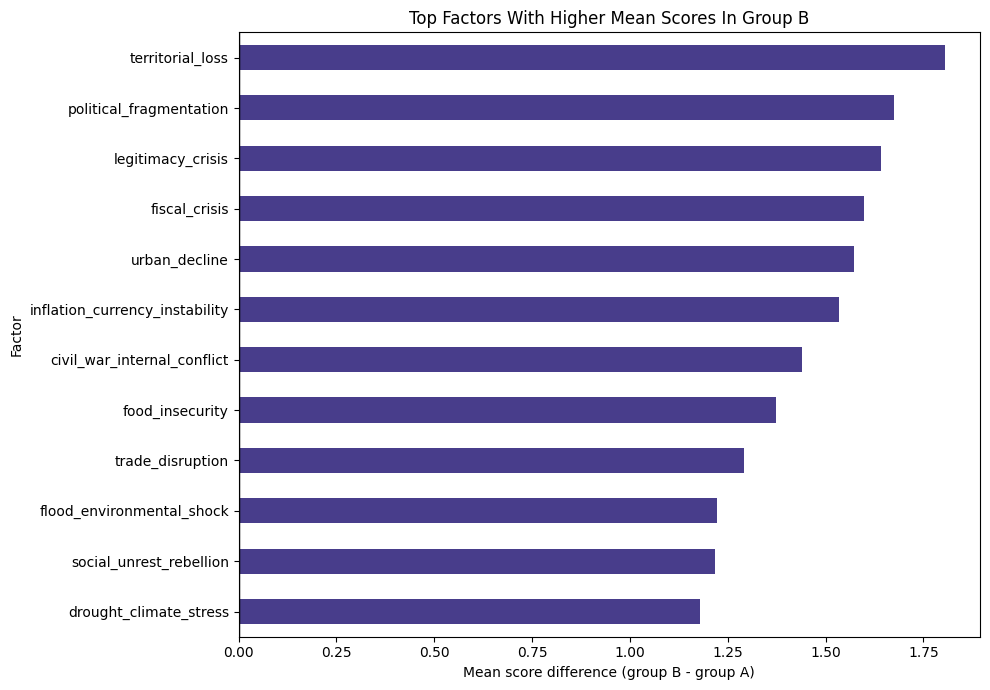

In [4]:
display(factor_comparison.round(3))

top_factors = factor_comparison.head(12).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
top_factors["score_difference"].plot(kind="barh", ax=ax, color="darkslateblue")
ax.set_title("Top Factors With Higher Mean Scores In Group B")
ax.set_xlabel("Mean score difference (group B - group A)")
ax.set_ylabel("Factor")
ax.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

## Category-Level Comparison

This section aggregates the same comparison by factor category.

,group_a_mean,group_b_mean,group_a_known_n,group_b_known_n,score_difference
category,,,,,
military_geopolitical,0.855,2.101,359,288,1.246
political,1.049,2.182,386,390,1.133
environmental,0.524,1.625,145,136,1.101
social,0.707,1.741,297,305,1.034
economic,0.974,1.881,390,353,0.907
resilience_institutional,2.138,1.376,456,394,-0.763


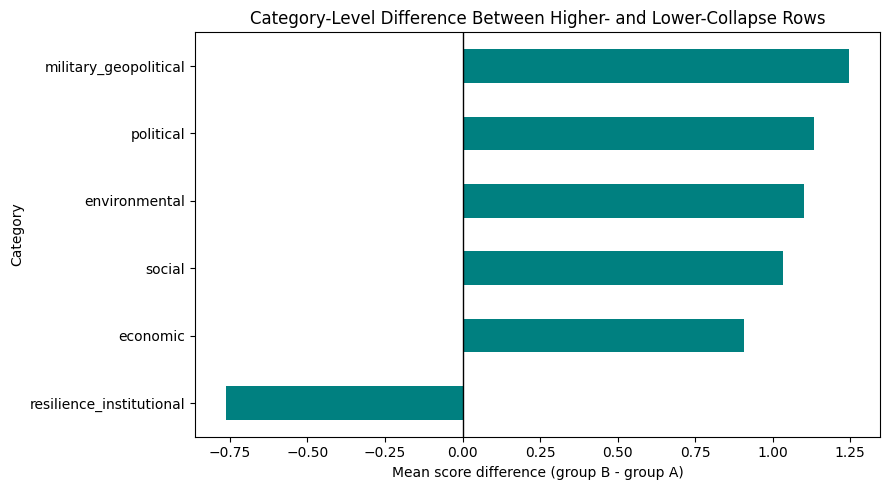

In [5]:
category_records = []
for category, columns in factor_categories.items():
    group_a_values = known_factor_data.loc[group_a_mask, columns]
    group_b_values = known_factor_data.loc[group_b_mask, columns]
    category_records.append(
        {
            "category": category,
            "group_a_mean": group_a_values.stack().mean(),
            "group_b_mean": group_b_values.stack().mean(),
            "group_a_known_n": int(group_a_values.notna().sum().sum()),
            "group_b_known_n": int(group_b_values.notna().sum().sum()),
        }
    )

category_comparison = pd.DataFrame(category_records).set_index("category")
category_comparison["score_difference"] = category_comparison["group_b_mean"] - category_comparison["group_a_mean"]
category_comparison = category_comparison.sort_values("score_difference", ascending=False)

display(category_comparison.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
category_comparison["score_difference"].iloc[::-1].plot(kind="barh", ax=ax, color="teal")
ax.set_title("Category-Level Difference Between Higher- and Lower-Collapse Rows")
ax.set_xlabel("Mean score difference (group B - group A)")
ax.set_ylabel("Category")
ax.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

## Short Interpretation

The comparison below is descriptive and uncertainty-aware. It shows which factors tend to be scored higher in rows already coded as more severe (`collapse_outcome` 2 or 3), but it does not imply that those factors alone cause collapse or that the dataset should be used as a predictive model.

In [6]:
top_factor_names = ", ".join(factor_comparison.head(5).index.tolist())
top_category_names = ", ".join(category_comparison.head(3).index.tolist())
group_a_rows = int(group_row_counts.loc['A_lower_collapse', 'row_count'])
group_b_rows = int(group_row_counts.loc['B_higher_collapse', 'row_count'])

interpretation_md = f"""
### Interpretation Notes

- Group A contains **{group_a_rows}** rows with `collapse_outcome` 0 or 1, and Group B contains **{group_b_rows}** rows with `collapse_outcome` 2 or 3.
- The largest factor-level increases in the higher-collapse group appear in **{top_factor_names}**.
- At the category level, the strongest average separation appears in **{top_category_names}**.
- Because `9` is excluded from the averages, these comparisons reflect only known scores and should always be read alongside the known-observation counts.
- This notebook is best used to guide interpretation and follow-up review, not to make deterministic claims about collapse causes.
"""

display(Markdown(interpretation_md))


### Interpretation Notes

- Group A contains **94** rows with `collapse_outcome` 0 or 1, and Group B contains **80** rows with `collapse_outcome` 2 or 3.
- The largest factor-level increases in the higher-collapse group appear in **territorial_loss, political_fragmentation, legitimacy_crisis, fiscal_crisis, urban_decline**.
- At the category level, the strongest average separation appears in **military_geopolitical, political, environmental**.
- Because `9` is excluded from the averages, these comparisons reflect only known scores and should always be read alongside the known-observation counts.
- This notebook is best used to guide interpretation and follow-up review, not to make deterministic claims about collapse causes.
